
## `01 — Exploratory Data Analysis`

| Module | Question |
|---|---|
| 1 — Structure | What do I have? |
| 2 — Quality | What's broken? |
| 3 — Statistics | What does it look like? |
| 4 — Plots | What does the data tell me visually? |

In [4]:
! pip install numpy pandas matplotlib seaborn scikit-learn seaborn --quiet


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 0. Setup

In [5]:
import sys
sys.path.append('..')

from eda_utils import (
    load_data,
    check_structure,
    check_quality,
    check_statistics,
    plot_distributions,
)

print('✅ Ready')

✅ Ready


In [30]:
import pandas as pd

---
## 1. Load Data

In [6]:
sales_df = load_data(
    filepath      = '../data/raw_sales_transactions.csv',
    stratify_col  = 'store_id',
    date_col      = 'date',
)

inventory_df = load_data(
    filepath      = '../data/daily_inventory_snapshots.csv',
    stratify_col  = 'store_id',
    date_col      = 'date',
)

catalog_df = load_data(
    filepath = '../data/product_catalog_metadata.csv',
)


📂 Loading: ../data/raw_sales_transactions.csv
   Total rows : 100,000
   Sampled    : 50,000 rows (stratified by 'store_id')

📂 Loading: ../data/daily_inventory_snapshots.csv
   Total rows : 31,300
   Small file — using all 31,300 rows

📂 Loading: ../data/product_catalog_metadata.csv
   Total rows : 50
   Small file — using all 50 rows


---
# 🔵 Sales Transactions

In [13]:
check_structure(sales_df, name='Sales Transactions')

---
## 🗂️ Structure — Sales Transactions

Rows    : 50,000
Columns : 5



,Column,Type,Non-Null,Null,Example
0,transaction_id,str,50000,0,TXN_124494
1,date,datetime64[us],16673,33327,2025-05-07 00:00:00
2,sku_id,str,50000,0,SKU_032
3,units_sold,int64,50000,0,13
4,price_point,float64,50000,0,346.96


**First 3 rows:**

,transaction_id,date,sku_id,units_sold,price_point
0,TXN_124494,2025-05-07,SKU_032,13,346.96
1,TXN_108151,2025-03-06,SKU_031,8,406.42
2,TXN_110592,NaT,SKU_046,5,466.47


In [14]:
check_quality(sales_df, name='Sales Transactions')

---
## 🔍 Quality — Sales Transactions

**Missing Values:**

  ⚠️  1 columns have missing values


,Column,Missing,Missing %
1,date,33327,66.65


**Duplicate Rows:**

  ✅ No duplicate rows found


In [15]:
check_statistics(sales_df, name='Sales Transactions')

---
## 📊 Statistics — Sales Transactions

**Numeric Summary:**

,count,mean,std,min,25%,50%,75%,max
units_sold,50000.0,9.05,5.36,-5.00,6.00,8.00,12.00,33.00
price_point,50000.0,255.26,141.55,10.01,133.36,254.92,377.68,499.99


**Categorical Columns — Top Values:**


  'transaction_id' — 31,530 unique values

  'sku_id' — 50 unique values


---
## 📈 Plots — Sales Transactions

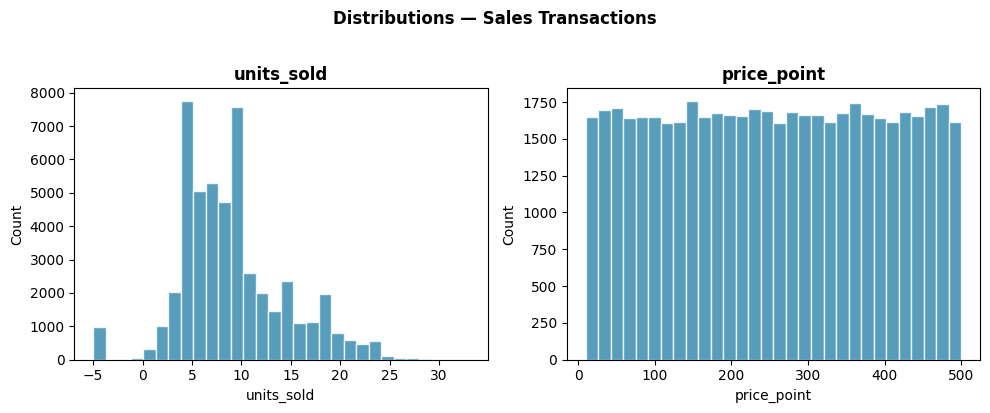

  💾 Saved → outputs/eda_reports/Sales_Transactions_histograms.png


In [16]:
plot_distributions(
    sales_df,
    name       = 'Sales Transactions',
    date_col   = 'date',
    target_col = 'quantity',   # ← change to your actual sales column name
)

---
# 🟢 Inventory Snapshots

In [17]:
check_structure(inventory_df, name='Inventory Snapshots')

---
## 🗂️ Structure — Inventory Snapshots

Rows    : 31,300
Columns : 4



,Column,Type,Non-Null,Null,Example
0,snapshot_date,str,31300,0,2024-01-01
1,sku_id,str,31300,0,SKU_001
2,stock_on_hand,int64,31300,0,14
3,reorder_point,int64,31300,0,25


**First 3 rows:**

,snapshot_date,sku_id,stock_on_hand,reorder_point
0,2024-01-01,SKU_001,14,25
1,2024-01-01,SKU_002,37,25
2,2024-01-01,SKU_003,32,25


In [18]:
check_quality(inventory_df, name='Inventory Snapshots')

---
## 🔍 Quality — Inventory Snapshots

**Missing Values:**

  ✅ No missing values found


**Duplicate Rows:**

  ✅ No duplicate rows found


In [19]:
check_statistics(inventory_df, name='Inventory Snapshots')

---
## 📊 Statistics — Inventory Snapshots

**Numeric Summary:**

,count,mean,std,min,25%,50%,75%,max
stock_on_hand,31300.0,54.94,26.12,10.0,32.0,55.0,77.0,100.0
reorder_point,31300.0,25.00,0.00,25.0,25.0,25.0,25.0,25.0


**Categorical Columns — Top Values:**


  'snapshot_date' — 626 unique values

  'sku_id' — 50 unique values


---
## 📈 Plots — Inventory Snapshots

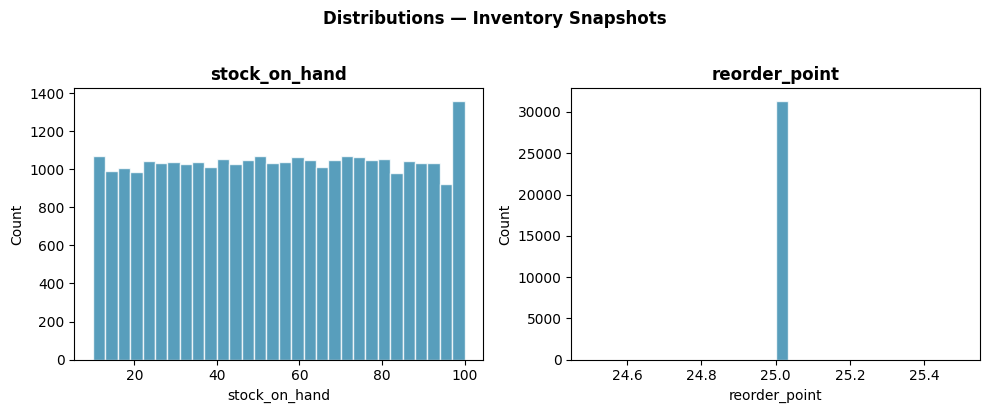

  💾 Saved → outputs/eda_reports/Inventory_Snapshots_histograms.png


In [20]:
plot_distributions(
    inventory_df,
    name       = 'Inventory Snapshots',
    date_col   = 'date',
    target_col = 'stock_on_hand',   # ← change to your actual column name
)

---
# 🟡 Product Catalog

In [21]:
check_structure(catalog_df, name='Product Catalog')

---
## 🗂️ Structure — Product Catalog

Rows    : 50
Columns : 4



,Column,Type,Non-Null,Null,Example
0,sku_id,str,50,0,SKU_001
1,category,str,50,0,Apparel
2,product_description,str,50,0,High-quality smart item.
3,is_promotional,bool,50,0,False


**First 3 rows:**

,sku_id,category,product_description,is_promotional
0,SKU_001,Apparel,High-quality smart item.,False
1,SKU_002,Fresh Produce,High-quality compact item.,True
2,SKU_003,Pet Supplies,High-quality compact item.,True


In [22]:
check_quality(catalog_df, name='Product Catalog')

---
## 🔍 Quality — Product Catalog

**Missing Values:**

  ✅ No missing values found


**Duplicate Rows:**

  ✅ No duplicate rows found


In [23]:
check_statistics(catalog_df, name='Product Catalog')

---
## 📊 Statistics — Product Catalog

**Categorical Columns — Top Values:**


  'sku_id' — 50 unique values

  'category' — 5 unique values


,count
category,
Apparel,12
Pet Supplies,11
Electronics,11
Fresh Produce,8
Home & Kitchen,8



  'product_description' — 4 unique values


,count
product_description,
High-quality durable item.,14
High-quality compact item.,13
High-quality organic item.,13
High-quality smart item.,10


---
## 📈 Plots — Product Catalog

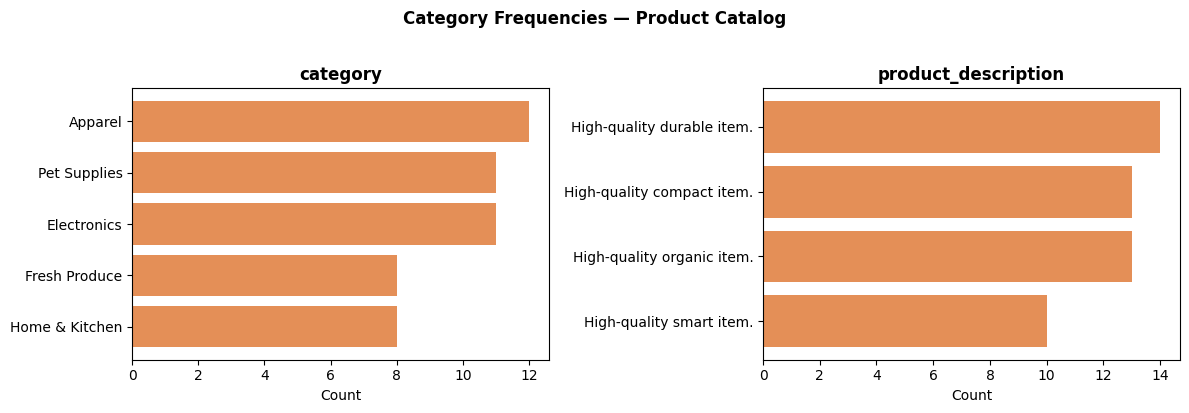

  💾 Saved → outputs/eda_reports/Product_Catalog_categories.png


In [24]:
plot_distributions(catalog_df, name='Product Catalog')

## Investigate the missing values in the transaction dataset

In [27]:
# ── Where are missing dates concentrated? ──────────────────────
missing_dates = sales_df[sales_df['date'].isna()]

print(f"Total rows with missing dates : {len(missing_dates):,}")
print(f"That is {len(missing_dates)/len(sales_df)*100:.1f}% of all rows\n")

Total rows with missing dates : 33,327
That is 66.7% of all rows



In [31]:
by_sku = (
    missing_dates['sku_id']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'sku_id', 'sku_id': 'missing_count'})
)
by_sku['missing_count'] = pd.to_numeric(by_sku['missing_count'], errors='coerce')
by_sku['missing_%'] = (by_sku['missing_count'] / len(sales_df) * 100).round(2)
display(by_sku.head(20))

,missing_count,count,missing_%
0,NaN,723,NaN
1,NaN,718,NaN
2,NaN,712,NaN
3,NaN,707,NaN
4,NaN,704,NaN
5,NaN,702,NaN
6,NaN,700,NaN
7,NaN,698,NaN
8,NaN,695,NaN
9,NaN,691,NaN


In [32]:
# How are missing dates spread across SKUs?
total_skus         = sales_df['sku_id'].nunique()
skus_with_missing  = sales_df[sales_df['date'].isna()]['sku_id'].nunique()

print(f"Total unique SKUs          : {total_skus}")
print(f"SKUs that have missing date: {skus_with_missing}")
print(f"That is {skus_with_missing/total_skus*100:.1f}% of all SKUs affected")

Total unique SKUs          : 50
SKUs that have missing date: 50
That is 100.0% of all SKUs affected


---
## 📝 Findings

| Issue | Dataset | Column | Finding | Action |
|---|---|---|---|---|
| 66% missing dates | Sales | `date` | All SKUs equally affected — system export bug | ⏳ To be decided in cleaning |